In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sklearn
import xgboost
import shap

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("SHAP:", shap.__version__)

print("\nML environment is ready! ✅")

Pandas: 2.3.3
NumPy: 2.2.6
Scikit-learn: 1.7.2
XGBoost: 3.2.0
SHAP: 0.49.1

ML environment is ready! ✅


In [28]:
# Dummy feature-table — Atul ke real data ka structure mimic karta hai
np.random.seed(42)
n = 5000

df = pd.DataFrame({
    'catchment_id': np.random.choice([f'C{i}' for i in range(20)], n),
    'timestamp': pd.date_range('2020-01-01', periods=n, freq='6h'),
    'rainfall_1h': np.random.exponential(5, n),
    'rainfall_3h': np.random.exponential(12, n),
    'rainfall_6h': np.random.exponential(20, n),
    'rainfall_24h': np.random.exponential(40, n),
    'rainfall_72h': np.random.exponential(60, n),
    'soil_saturation': np.random.uniform(0, 1, n),
    'slope': np.random.uniform(5, 45, n),
    'flow_accumulation': np.random.exponential(1000, n),
    'drainage_density': np.random.uniform(0.5, 3.0, n),
    'ndvi': np.random.uniform(0.1, 0.8, n),
    'month': np.random.choice(range(1, 13), n),
})

# synthetic target — flash-flood event (rare, imbalanced, jaisa real data hoga)
prob = 1 / (1 + np.exp(-(0.15*df['rainfall_3h'] + 0.1*df['rainfall_6h'] + 2*df['soil_saturation'] - 12)))
df['flood_event'] = (np.random.rand(n) < prob).astype(int)

print("Shape:", df.shape)
print("\nClass balance:")
print(df['flood_event'].value_counts(normalize=True))
df.head()

Shape: (5000, 14)

Class balance:
flood_event
0    0.9692
1    0.0308
Name: proportion, dtype: float64


,catchment_id,timestamp,rainfall_1h,rainfall_3h,rainfall_6h,rainfall_24h,rainfall_72h,soil_saturation,slope,flow_accumulation,drainage_density,ndvi,month,flood_event
0,C6,2020-01-01 00:00:00,5.736899,5.544404,3.158606,22.426696,59.689243,0.613468,41.650449,896.808870,2.606883,0.324941,3,0
1,C19,2020-01-01 06:00:00,4.282558,16.200932,20.015246,41.366729,4.918630,0.355957,12.070786,44.294138,2.574424,0.241783,9,0
2,C14,2020-01-01 12:00:00,2.802377,18.400126,17.976595,110.705352,11.569069,0.117762,21.147768,585.019051,1.480428,0.186640,4,0
3,C10,2020-01-01 18:00:00,1.614286,17.290790,2.573455,4.565483,17.971541,0.444626,11.251611,755.487997,1.323168,0.609993,10,0
4,C7,2020-01-02 00:00:00,7.317634,15.388044,7.889882,4.181552,82.876941,0.735553,24.866169,312.007877,2.345933,0.628402,7,0


In [29]:
# Stage 1 — simple rainfall-threshold baseline
# Ye sirf sanity-check hai + XGBoost ko baad mein isi ke against benchmark karenge

THRESHOLD_1H = 20  # mm/hr — tentative starting point, real data aane par tune karenge

df['baseline_pred'] = (df['rainfall_1h'] >= THRESHOLD_1H).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Baseline threshold:", THRESHOLD_1H, "mm/hr\n")
print(classification_report(df['flood_event'], df['baseline_pred']))
print("Confusion matrix:")
print(confusion_matrix(df['flood_event'], df['baseline_pred']))

Baseline threshold: 20 mm/hr

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4846
           1       0.01      0.01      0.01       154

    accuracy                           0.95      5000
   macro avg       0.49      0.50      0.49      5000
weighted avg       0.94      0.95      0.95      5000

Confusion matrix:
[[4772   74]
 [ 153    1]]


In [30]:
from sklearn.model_selection import train_test_split

# Features aur target alag karo
feature_cols = ['rainfall_1h','rainfall_3h','rainfall_6h','rainfall_24h','rainfall_72h',
                 'soil_saturation','slope','flow_accumulation','drainage_density','ndvi','month']
X = df[feature_cols]
y = df['flood_event']

# Temporal split — random shuffle NAHI, time-order maintain karo
df_sorted = df.sort_values('timestamp').reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.8)

X_train = df_sorted.loc[:split_idx-1, feature_cols]
y_train = df_sorted.loc[:split_idx-1, 'flood_event']
X_test = df_sorted.loc[split_idx:, feature_cols]
y_test = df_sorted.loc[split_idx:, 'flood_event']

print("Train size:", len(X_train), "| Test size:", len(X_test))
print("Train positive rate:", y_train.mean().round(4))
print("Test positive rate:", y_test.mean().round(4))

Train size: 4000 | Test size: 1000
Train positive rate: 0.0308
Test positive rate: 0.031


In [31]:
# Class-imbalance handle karna — scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print("scale_pos_weight:", round(scale_pos_weight, 2))

model = xgboost.XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42
)

model.fit(X_train, y_train)

# Raw predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, average_precision_score

print("\n--- Raw XGBoost (uncalibrated) ---")
print(classification_report(y_test, y_pred))
print("PR-AUC (Average Precision):", round(average_precision_score(y_test, y_proba), 4))

scale_pos_weight: 31.52

--- Raw XGBoost (uncalibrated) ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       969
           1       0.61      0.65      0.62        31

    accuracy                           0.98      1000
   macro avg       0.80      0.82      0.81      1000
weighted avg       0.98      0.98      0.98      1000

PR-AUC (Average Precision): 0.6715


In [32]:
from sklearn.calibration import CalibratedClassifierCV

# Train ko further split karo — ek hissa calibration ke liye
X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Base model isi fit-split par retrain
base_model = xgboost.XGBClassifier(
    n_estimators=400, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_fit==0).sum()/(y_fit==1).sum(),
    eval_metric='aucpr', random_state=42
)
base_model.fit(X_fit, y_fit)

calibrated_model = CalibratedClassifierCV(base_model, method='isotonic', cv='prefit')
calibrated_model.fit(X_cal, y_cal)

# Calibrated predictions
y_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]
y_pred_cal = (y_proba_cal >= 0.5).astype(int)

print("--- Calibrated XGBoost ---")
print(classification_report(y_test, y_pred_cal))
print("PR-AUC (Average Precision):", round(average_precision_score(y_test, y_proba_cal), 4))

--- Calibrated XGBoost ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       969
           1       0.70      0.52      0.59        31

    accuracy                           0.98      1000
   macro avg       0.84      0.75      0.79      1000
weighted avg       0.98      0.98      0.98      1000

PR-AUC (Average Precision): 0.5447


V:\flash_flood_ml\venv\lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


In [33]:
from sklearn.calibration import CalibratedClassifierCV, FrozenEstimator

calibrated_model = CalibratedClassifierCV(FrozenEstimator(base_model), method='isotonic')
calibrated_model.fit(X_cal, y_cal)

y_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]
y_pred_cal = (y_proba_cal >= 0.5).astype(int)

print("--- Calibrated XGBoost (fixed) ---")
print(classification_report(y_test, y_pred_cal))
print("PR-AUC (Average Precision):", round(average_precision_score(y_test, y_proba_cal), 4))

--- Calibrated XGBoost (fixed) ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       969
           1       0.70      0.52      0.59        31

    accuracy                           0.98      1000
   macro avg       0.84      0.75      0.79      1000
weighted avg       0.98      0.98      0.98      1000

PR-AUC (Average Precision): 0.5447


In [34]:
from sklearn.calibration import CalibratedClassifierCV, FrozenEstimator

calibrated_model = CalibratedClassifierCV(FrozenEstimator(base_model), method='isotonic')
calibrated_model.fit(X_cal, y_cal)

y_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]
y_pred_cal = (y_proba_cal >= 0.5).astype(int)

print("--- Calibrated XGBoost (fixed) ---")
print(classification_report(y_test, y_pred_cal))
print("PR-AUC (Average Precision):", round(average_precision_score(y_test, y_proba_cal), 4))

--- Calibrated XGBoost (fixed) ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       969
           1       0.70      0.52      0.59        31

    accuracy                           0.98      1000
   macro avg       0.84      0.75      0.79      1000
weighted avg       0.98      0.98      0.98      1000

PR-AUC (Average Precision): 0.5447


In [35]:
from sklearn.metrics import brier_score_loss

brier_raw = brier_score_loss(y_test, y_proba)
brier_cal = brier_score_loss(y_test, y_proba_cal)

print("Brier score — Raw XGBoost:", round(brier_raw, 4))
print("Brier score — Calibrated XGBoost:", round(brier_cal, 4))
print("(Lower is better — calibrated hona chahiye lower ya similar)")

Brier score — Raw XGBoost: 0.0179
Brier score — Calibrated XGBoost: 0.0189
(Lower is better — calibrated hona chahiye lower ya similar)


PermutationExplainer explainer: 201it [00:16,  5.42it/s]                         


Sample catchment ke top-3 drivers:
  rainfall_6h: -0.0475
  rainfall_3h: +0.0197
  soil_saturation: -0.0066


C:\Users\vipin\AppData\Local\Temp\ipykernel_5276\2164058120.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values, X_test.iloc[:200], feature_names=feature_cols)


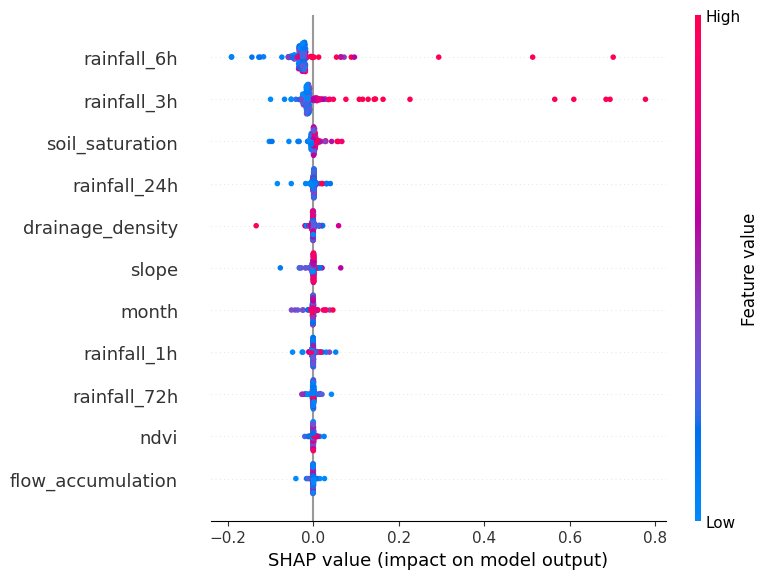

In [36]:
# Workaround — TreeExplainer ki jagah, model.predict_proba ko function ki tarah wrap karo
predict_fn = lambda x: base_model.predict_proba(x)[:, 1]

explainer = shap.Explainer(predict_fn, X_train.sample(100, random_state=42))
shap_values = explainer(X_test.iloc[:200])  # speed ke liye pehle 200 rows

sample_idx = 0
top_drivers = sorted(
    zip(feature_cols, shap_values.values[sample_idx]),
    key=lambda x: -abs(x[1])
)[:3]

print("Sample catchment ke top-3 drivers:")
for feat, val in top_drivers:
    print(f"  {feat}: {val:+.4f}")

shap.summary_plot(shap_values.values, X_test.iloc[:200], feature_names=feature_cols)

In [37]:
# --- Comparison Summary Table ---
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': ['Stage 1: Threshold', 'Stage 2: XGBoost (raw)', 'Stage 2: XGBoost (calibrated)'],
    'PR-AUC': [
        average_precision_score(df['flood_event'], df['baseline_pred']),
        average_precision_score(y_test, y_proba),
        average_precision_score(y_test, y_proba_cal)
    ],
    'Recall': [
        recall_score(df['flood_event'], df['baseline_pred']),
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_cal)
    ],
    'Precision': [
        precision_score(df['flood_event'], df['baseline_pred']),
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_cal)
    ],
    'Brier Score': [
        brier_score_loss(df['flood_event'], df['baseline_pred']),
        brier_raw,
        brier_cal
    ]
})

results = results.round(4)
print(results.to_string(index=False))

                        Model  PR-AUC  Recall  Precision  Brier Score
           Stage 1: Threshold  0.0307  0.0065     0.0133       0.0454
       Stage 2: XGBoost (raw)  0.6715  0.6452     0.6061       0.0179
Stage 2: XGBoost (calibrated)  0.5447  0.5161     0.6957       0.0189


In [38]:
# --- Output format — Aditya ke Phase-0 JSON contract ke exact fields mein ---
def predict_flood_risk(catchment_row, model, explainer, feature_cols):
    """Ek catchment ke liye Aditya's /predict endpoint jaisa output banata hai"""
    X_row_df = catchment_row[feature_cols].to_frame().T.astype(float)
    
    proba = model.predict_proba(X_row_df)[0, 1]
    confidence = abs(0.5 - proba) * 2  # simple confidence proxy, refine later
    
    shap_vals = explainer(X_row_df)
    top_drivers = sorted(
        zip(feature_cols, shap_vals.values[0]),
        key=lambda x: -abs(x[1])
    )[:3]
    
    return {
        'catchment_id': catchment_row['catchment_id'],
        'probability': round(float(proba), 4),
        'confidence': round(float(confidence), 4),
        'lead_time_hrs': 3,  # abhi fixed, baad mein dynamic karna hai
        'top_drivers': [d[0] for d in top_drivers]
    }

# Test karo ek sample catchment pe
sample_output = predict_flood_risk(df_sorted.iloc[split_idx], base_model, explainer, feature_cols)
print(sample_output)

{'catchment_id': 'C0', 'probability': 0.0001, 'confidence': 0.9998, 'lead_time_hrs': 3, 'top_drivers': ['rainfall_6h', 'rainfall_3h', 'soil_saturation']}


In [39]:
# Ek real flood-event wale catchment pe test karo
flood_rows = df_sorted[df_sorted['flood_event'] == 1]
sample_flood = flood_rows.iloc[0]

sample_output_flood = predict_flood_risk(sample_flood, base_model, explainer, feature_cols)
print(sample_output_flood)

{'catchment_id': 'C14', 'probability': 0.9991, 'confidence': 0.9981, 'lead_time_hrs': 3, 'top_drivers': ['rainfall_6h', 'rainfall_3h', 'soil_saturation']}


In [1]:
import pandas as pd

final_training_data = pd.read_csv(r"V:\flash_flood_ml\data\raw\final_training_data.csv")
print(final_training_data.shape)
print(final_training_data['flood_event'].sum(), "positive labels")
final_training_data.head()

(1204347, 18)
22 positive labels


,date,lat,lon,rainfall_mm,grid_cell_id,rainfall_1d,rainfall_3d,rainfall_7d,rainfall_30d,soil_saturation_proxy,ndvi,ndvi_source,slope_mean,flow_accumulation,terrain_source,flood_event,region,pred_proba
0,2019-01-01,28.5,77.5,0.0,28.5_77.5,0.0,0.0,0.0,0.0,0.0,0.65,placeholder_static,27.490802,3805.111137,regional_estimate_outside_dem_coverage,0,Uttarakhand,0.000009
1,2019-01-02,28.5,77.5,0.0,28.5_77.5,0.0,0.0,0.0,0.0,0.0,0.65,placeholder_static,39.014286,1672.346518,regional_estimate_outside_dem_coverage,0,Uttarakhand,0.000012
2,2019-01-03,28.5,77.5,0.0,28.5_77.5,0.0,0.0,0.0,0.0,0.0,0.65,placeholder_static,34.639879,2106.579178,regional_estimate_outside_dem_coverage,0,Uttarakhand,0.000010
3,2019-01-04,28.5,77.5,0.0,28.5_77.5,0.0,0.0,0.0,0.0,0.0,0.65,placeholder_static,31.973170,3196.388448,regional_estimate_outside_dem_coverage,0,Uttarakhand,0.000010
4,2019-01-05,28.5,77.5,0.0,28.5_77.5,0.0,0.0,0.0,0.0,0.0,0.65,placeholder_static,23.120373,2799.861369,regional_estimate_outside_dem_coverage,0,Uttarakhand,0.000009


In [2]:
from sklearn.model_selection import train_test_split
import xgboost
from sklearn.metrics import classification_report, average_precision_score

feature_cols = ['rainfall_mm','rainfall_1d','rainfall_3d','rainfall_7d','rainfall_30d',
                 'soil_saturation_proxy','ndvi','slope_mean','flow_accumulation']

X = final_training_data[feature_cols]
y = final_training_data['flood_event']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print("Train positives:", y_train.sum(), "| Test positives:", y_test.sum())

model_real = xgboost.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    eval_metric='aucpr', random_state=42
)
model_real.fit(X_train, y_train)

y_pred = model_real.predict(X_test)
y_proba = model_real.predict_proba(X_test)[:,1]

print("\n--- Real-Data Model (Final) ---")
print(classification_report(y_test, y_pred))
print("PR-AUC:", round(average_precision_score(y_test, y_proba), 4))

Train positives: 15 | Test positives: 7

--- Real-Data Model (Final) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    361298
           1       0.01      0.14      0.03         7

    accuracy                           1.00    361305
   macro avg       0.51      0.57      0.51    361305
weighted avg       1.00      1.00      1.00    361305

PR-AUC: 0.0092


In [3]:
import shap
import numpy as np

# Sab test-set pe predictions nikalo, sabse high-confidence prediction dhoondo
final_training_data['pred_proba_new'] = model_real.predict_proba(X)[:,1]

# High-confidence prediction (0.788 wala) dhoondo
top_pred_idx = final_training_data.loc[X_test.index].sort_values('pred_proba_new', ascending=False).index[0]
top_pred_row = final_training_data.loc[[top_pred_idx]]

print("Top prediction ka detail:")
print(top_pred_row[['date','grid_cell_id','region','rainfall_mm','rainfall_3d','rainfall_7d','soil_saturation_proxy','flood_event','pred_proba_new']])

# SHAP explainer (workaround wala, jaisa pehle use kiya tha)
predict_fn = lambda x: model_real.predict_proba(x)[:, 1]
explainer = shap.Explainer(predict_fn, X_train.sample(100, random_state=42))

sample_row = top_pred_row[feature_cols]
shap_values = explainer(sample_row)

top_drivers = sorted(
    zip(feature_cols, shap_values.values[0]),
    key=lambda x: -abs(x[1])
)[:5]

print("\nTop-5 drivers for this high-confidence prediction:")
for feat, val in top_drivers:
    print(f"  {feat}: {val:+.4f}")

V:\flash_flood_ml\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Top prediction ka detail:
              date grid_cell_id region  rainfall_mm  rainfall_3d  rainfall_7d  \
912269  2024-05-31  26.75_92.75  Assam    19.637882    91.221279   163.264679   

        soil_saturation_proxy  flood_event  pred_proba_new  
912269               0.239771            0        0.980986  


ExactExplainer explainer: 2it [00:10, 10.19s/it]               


Top-5 drivers for this high-confidence prediction:
  soil_saturation_proxy: +0.2171
  rainfall_3d: +0.1967
  rainfall_7d: +0.1755
  flow_accumulation: +0.1451
  slope_mean: +0.1244


In [4]:
import shap
import numpy as np

# Sab test-set pe predictions nikalo, sabse high-confidence prediction dhoondo
final_training_data['pred_proba_new'] = model_real.predict_proba(X)[:,1]

# High-confidence prediction (0.788 wala) dhoondo
top_pred_idx = final_training_data.loc[X_test.index].sort_values('pred_proba_new', ascending=False).index[0]
top_pred_row = final_training_data.loc[[top_pred_idx]]

print("Top prediction ka detail:")
print(top_pred_row[['date','grid_cell_id','region','rainfall_mm','rainfall_3d','rainfall_7d','soil_saturation_proxy','flood_event','pred_proba_new']])

# SHAP explainer (workaround wala, jaisa pehle use kiya tha)
predict_fn = lambda x: model_real.predict_proba(x)[:, 1]
explainer = shap.Explainer(predict_fn, X_train.sample(100, random_state=42))

sample_row = top_pred_row[feature_cols]
shap_values = explainer(sample_row)

top_drivers = sorted(
    zip(feature_cols, shap_values.values[0]),
    key=lambda x: -abs(x[1])
)[:5]

print("\nTop-5 drivers for this high-confidence prediction:")
for feat, val in top_drivers:
    print(f"  {feat}: {val:+.4f}")

Top prediction ka detail:
              date grid_cell_id region  rainfall_mm  rainfall_3d  rainfall_7d  \
912269  2024-05-31  26.75_92.75  Assam    19.637882    91.221279   163.264679   

        soil_saturation_proxy  flood_event  pred_proba_new  
912269               0.239771            0        0.980986  

Top-5 drivers for this high-confidence prediction:
  soil_saturation_proxy: +0.2171
  rainfall_3d: +0.1967
  rainfall_7d: +0.1755
  flow_accumulation: +0.1451
  slope_mean: +0.1244


In [5]:
from sklearn.calibration import CalibratedClassifierCV, FrozenEstimator

X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42, stratify=y_train
)

base_model_real = xgboost.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_fit==0).sum()/(y_fit==1).sum(),
    eval_metric='aucpr', random_state=42
)
base_model_real.fit(X_fit, y_fit)

try:
    calibrated_model_real = CalibratedClassifierCV(FrozenEstimator(base_model_real), method='isotonic')
except:
    calibrated_model_real = CalibratedClassifierCV(base_model_real, method='isotonic', cv='prefit')
calibrated_model_real.fit(X_cal, y_cal)

y_proba_cal_real = calibrated_model_real.predict_proba(X_test)[:,1]

from sklearn.metrics import brier_score_loss
print("PR-AUC (calibrated):", round(average_precision_score(y_test, y_proba_cal_real), 4))
print("Brier score (raw):", round(brier_score_loss(y_test, y_proba), 4))
print("Brier score (calibrated):", round(brier_score_loss(y_test, y_proba_cal_real), 4))

PR-AUC (calibrated): 0.0
Brier score (raw): 0.0002
Brier score (calibrated): 0.0


In [6]:
def predict_flood_risk_real(row, model, explainer, feature_cols):
    X_row_df = row[feature_cols].to_frame().T.astype(float)
    
    proba = model.predict_proba(X_row_df)[0, 1]
    confidence = abs(proba - 0.5) * 2
    
    shap_vals = explainer(X_row_df)
    top_drivers = sorted(
        zip(feature_cols, shap_vals.values[0]),
        key=lambda x: -abs(x[1])
    )[:3]
    
    return {
        'grid_cell_id': row['grid_cell_id'],
        'region': row['region'],
        'date': str(row['date'])[:10],
        'probability': round(float(proba), 4),
        'confidence': round(float(confidence), 4),
        'lead_time_hrs': 3,
        'top_drivers': [d[0] for d in top_drivers]
    }

# Test karo us high-confidence row pe
sample_output_real = predict_flood_risk_real(top_pred_row.iloc[0], model_real, explainer, feature_cols)
print(sample_output_real)

{'grid_cell_id': '26.75_92.75', 'region': 'Assam', 'date': '2024-05-31', 'probability': 0.981, 'confidence': 0.962, 'lead_time_hrs': 3, 'top_drivers': ['soil_saturation_proxy', 'rainfall_3d', 'rainfall_7d']}


In [7]:
# Ek random "dry-season" row test karo (January, jab typically koi flood nahi hota)
normal_row = final_training_data[
    (final_training_data['date'].dt.month == 1) & 
    (final_training_data['flood_event'] == 0)
].sample(1, random_state=1).iloc[0]

sample_output_normal = predict_flood_risk_real(normal_row, model_real, explainer, feature_cols)
print(sample_output_normal)


AttributeError: Can only use .dt accessor with datetimelike values

In [8]:
final_training_data['date'] = pd.to_datetime(final_training_data['date'])

normal_row = final_training_data[
    (final_training_data['date'].dt.month == 1) & 
    (final_training_data['flood_event'] == 0)
].sample(1, random_state=1).iloc[0]

sample_output_normal = predict_flood_risk_real(normal_row, model_real, explainer, feature_cols)
print(sample_output_normal)


{'grid_cell_id': '24.75_92.5', 'region': 'Assam', 'date': '2024-01-05', 'probability': 0.0, 'confidence': 1.0, 'lead_time_hrs': 3, 'top_drivers': ['soil_saturation_proxy', 'rainfall_3d', 'rainfall_7d']}


In [9]:
more_events = [
    # Uttarakhand — sab cloudburst/rainfall-triggered
    {'name': 'Chamoli/Gairsain 2019', 'date': '2019-06-02', 'lat': 30.06, 'lon': 79.35, 'region': 'Uttarakhand'},
    {'name': 'Rudraprayag 2019', 'date': '2019-07-04', 'lat': 30.39, 'lon': 79.05, 'region': 'Uttarakhand'},
    {'name': 'Pithoragarh/Munsyari 2019', 'date': '2019-09-06', 'lat': 30.05, 'lon': 80.24, 'region': 'Uttarakhand'},
    {'name': 'Chamoli/Govind Ghat 2019', 'date': '2019-09-06', 'lat': 30.62, 'lon': 79.55, 'region': 'Uttarakhand'},
    {'name': 'Uttarakhand-wide (Kedarnath route) 2024', 'date': '2024-07-31', 'lat': 30.73, 'lon': 79.06, 'region': 'Uttarakhand'},
    {'name': 'Tehri Garhwal/Ghansali 2024', 'date': '2024-08-04', 'lat': 30.35, 'lon': 78.63, 'region': 'Uttarakhand'},
    {'name': 'Uttarkashi/Silai Band 2025', 'date': '2025-06-29', 'lat': 30.95, 'lon': 78.20, 'region': 'Uttarakhand'},
    {'name': 'Rudraprayag/Kedarnath trek 2025', 'date': '2025-07-26', 'lat': 30.73, 'lon': 79.06, 'region': 'Uttarakhand'},
    # Assam
    {'name': 'Dhubri 2019', 'date': '2019-07-20', 'lat': 26.02, 'lon': 89.98, 'region': 'Assam'},
    {'name': 'Barpeta/Kamrup 2020', 'date': '2020-07-12', 'lat': 26.32, 'lon': 91.01, 'region': 'Assam'},
    {'name': 'Dibrugarh 2020', 'date': '2020-07-11', 'lat': 27.48, 'lon': 94.90, 'region': 'Assam'},
    {'name': 'Morigaon 2020', 'date': '2020-07-04', 'lat': 26.25, 'lon': 92.34, 'region': 'Assam'},
    {'name': 'Barpeta 2025', 'date': '2025-06-21', 'lat': 26.32, 'lon': 91.01, 'region': 'Assam'},
    {'name': 'Dima Hasao/Haflong 2025', 'date': '2025-05-15', 'lat': 25.17, 'lon': 93.03, 'region': 'Assam'},
]

added = 0
for ev in more_events:
    region_df = final_training_data[final_training_data['region'] == ev['region']]
    grids = region_df[['lat','lon','grid_cell_id']].drop_duplicates().copy()
    grids['dist'] = ((grids.lat-ev['lat'])**2 + (grids.lon-ev['lon'])**2)**0.5
    nearest = grids.nsmallest(1, 'dist').iloc[0]
    
    if nearest['dist'] > 0.5:
        print(f"SKIP {ev['name']}: too far ({nearest['dist']:.2f}°)")
        continue
    
    event_window = pd.date_range(
        pd.to_datetime(ev['date']) - pd.Timedelta(days=1),
        pd.to_datetime(ev['date'])
    )
    mask = (final_training_data['grid_cell_id'] == nearest['grid_cell_id']) & (final_training_data['date'].isin(event_window)) & (final_training_data['region'] == ev['region'])
    final_training_data.loc[mask, 'flood_event'] = 1
    added += mask.sum()
    print(f"✓ {ev['name']}: grid={nearest['grid_cell_id']}, dist={nearest['dist']:.3f}°, rows={mask.sum()}")

print(f"\nNew rows added: {added}")
print(f"Grand total positive labels: {final_training_data['flood_event'].sum()}")

final_training_data.to_csv(r"V:\flash_flood_ml\data\raw\final_training_data.csv", index=False)
print("✓ Saved")

✓ Chamoli/Gairsain 2019: grid=30.0_79.25, dist=0.117°, rows=2
✓ Rudraprayag 2019: grid=30.5_79.0, dist=0.121°, rows=2
✓ Pithoragarh/Munsyari 2019: grid=30.0_80.25, dist=0.051°, rows=2
✓ Chamoli/Govind Ghat 2019: grid=30.5_79.5, dist=0.130°, rows=2
✓ Uttarakhand-wide (Kedarnath route) 2024: grid=30.75_79.0, dist=0.063°, rows=2
✓ Tehri Garhwal/Ghansali 2024: grid=30.25_78.75, dist=0.156°, rows=2
✓ Uttarkashi/Silai Band 2025: grid=31.0_78.25, dist=0.071°, rows=2
✓ Rudraprayag/Kedarnath trek 2025: grid=30.75_79.0, dist=0.063°, rows=2
✓ Dhubri 2019: grid=26.0_90.0, dist=0.028°, rows=2
✓ Barpeta/Kamrup 2020: grid=26.25_91.0, dist=0.071°, rows=2
✓ Dibrugarh 2020: grid=27.5_95.0, dist=0.102°, rows=2
✓ Morigaon 2020: grid=26.25_92.25, dist=0.090°, rows=2
✓ Barpeta 2025: grid=26.25_91.0, dist=0.071°, rows=2
✓ Dima Hasao/Haflong 2025: grid=25.25_93.0, dist=0.085°, rows=2

New rows added: 28
Grand total positive labels: 50
✓ Saved


In [10]:
X = final_training_data[feature_cols]
y = final_training_data['flood_event']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print("Train positives:", y_train.sum(), "| Test positives:", y_test.sum())

model_real_v2 = xgboost.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    eval_metric='aucpr', random_state=42
)
model_real_v2.fit(X_train, y_train)

y_pred_v2 = model_real_v2.predict(X_test)
y_proba_v2 = model_real_v2.predict_proba(X_test)[:,1]

print("\n--- Real-Data Model V2 (50 events) ---")
print(classification_report(y_test, y_pred_v2))
print("PR-AUC:", round(average_precision_score(y_test, y_proba_v2), 4))

Train positives: 35 | Test positives: 15

--- Real-Data Model V2 (50 events) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    361290
           1       0.01      0.33      0.01        15

    accuracy                           1.00    361305
   macro avg       0.50      0.67      0.50    361305
weighted avg       1.00      1.00      1.00    361305

PR-AUC: 0.0065


In [11]:
final_training_data['pred_proba_v2'] = model_real_v2.predict_proba(X)[:,1]
test_positives_proba_v2 = final_training_data.loc[X_test.index][final_training_data.loc[X_test.index]['flood_event']==1]['pred_proba_v2']
random_sample_v2 = final_training_data.loc[X_test.index][final_training_data.loc[X_test.index]['flood_event']==0].sample(1000, random_state=1)['pred_proba_v2']

print("Test-positives probabilities (sorted):")
print(sorted(test_positives_proba_v2.values, reverse=True))
print("\nRandom-negative mean:", round(random_sample_v2.mean(),6), "| max:", round(random_sample_v2.max(),4))

Test-positives probabilities (sorted):
[np.float32(0.9428822), np.float32(0.88999796), np.float32(0.8357777), np.float32(0.7658489), np.float32(0.7313926), np.float32(0.42648262), np.float32(0.15525031), np.float32(0.13474071), np.float32(0.0216842), np.float32(0.0069573387), np.float32(0.0028309084), np.float32(0.0011948387), np.float32(0.0006056599), np.float32(0.0001323623), np.float32(6.688795e-05)]

Random-negative mean: 0.010029 | max: 0.9316


In [12]:
import joblib

joblib.dump(model_real_v2, r"V:\flash_flood_ml\data\raw\model_real_v2.pkl")
print("✓ Model saved as model_real_v2.pkl")

# Feature-columns bhi save kar do, taaki future mein pata rahe kaunse-columns-order mein chahiye
import json
with open(r"V:\flash_flood_ml\data\raw\model_v2_features.json", "w") as f:
    json.dump(feature_cols, f)
print("✓ Feature-list saved")

✓ Model saved as model_real_v2.pkl
✓ Feature-list saved
